<a href="https://colab.research.google.com/github/Nouha89-git/-Deep-Learning-and-Neural-Networks-Checkpoint/blob/main/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2018 The TensorFlow Authors.

In [6]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/examples/blob/master/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/examples/blob/master/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

Welcome to this Colab where you will get a quick introduction to the Python programming language and the environment used for the course's exercises: Colab.

Colab is a Python development environment that runs in the browser using Google Cloud.

For example, to print "Hello World", just hover the mouse over [ ] and press the play button to the upper left. Or press shift-enter to execute.

In [4]:
# ═══════════════════════════════════════════════════
# RELANCE COMPLÈTE — colle et exécute cette cellule
# ═══════════════════════════════════════════════════

# ── Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.linalg import svd
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, spearmanr
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
PAL = {"C0": "#185FA5", "C1": "#D85A30", "C2": "#3C9E6E"}
plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

# ── Chargement ──────────────────────────────────────
df_raw = pd.read_excel("/content/article_rymel.xlsx", sheet_name="nouha_draft")
RENAME = {
    "Age":"age","Area (m²)":"superficie","Floor":"etage",
    "Are you on the top floor ?":"dernier_etage","Facade orientation":"orientation",
    "Windows material":"mat_fenetres","Glass type":"vitrage_type",
    "Single glazing":"vitrage_simple","Double glazing":"vitrage_double",
    "Shutter state":"volet_etat","Roof waterproofing status":"toiture_etat",
    "Does air get through closed windows?":"infiltr_air",
    "Water infiltration":"infiltr_eau","Moisture and mold":"humidite",
    "Do you experience cold drafts frequently?":"courants_froids",
    "How would you rate the temperature in the rooms facing the street (or the main facade)?":"sensation",
    "Summer thermal satisfaction":"sat_ete","Winter thermal satisfaction":"sat_hiver",
    "Rate thermal comfort":"score_confort",
    "Turn on a fan/the AC":"beh_fan_ac","Close the shutters":"beh_volets_ete",
    "Open the windows":"beh_fen_ouv"," Put on lighter clothes":"beh_vets_legers",
    "Turn on or turn up the heating":"beh_chauffage",
    "Put on warmer clothes":"beh_vets_chauds","Close the windows":"beh_fen_ferm",
    "Occupant status":"statut",
}
df = df_raw.rename(columns={k:v for k,v in RENAME.items() if k in df_raw.columns})

# ── Encodage ────────────────────────────────────────
sat_map = {"-2 dissatisfied":-2,"-1 Somewhat dissatisfied":-1,
           "0 Acceptable":0,"+1 Somewhat satisfied":1,"+2 Satisfied":2}
for col in ["sat_ete","sat_hiver"]:
    df[col+"_num"] = df[col].map(sat_map)

sens_map = {"-2 Very cold":-2,"-2 Cold":-2,"-1 Slightly chilly":-1,
            "-1 Cool":-1,"0 Neutral":0,"0 Comfortable":0,"+1 Slightly hot":1,"+2 Hot":2}
df["sensation_num"] = df["sensation"].map(sens_map)

for col in ["infiltr_air","infiltr_eau","humidite","courants_froids"]:
    df[col+"_bin"] = (df[col]=="Yes").astype(int)

df["vitrage_simple_bin"] = df["vitrage_type"].apply(
    lambda x: 0 if ("Double" in str(x) and "Single" not in str(x)) else 1)

for col, mapping in [("volet_etat",{"Good":2,"Medium":1,"Degraded":0}),
                     ("toiture_etat",{"Good":2,"Medium":1,"Degraded":0})]:
    df[col+"_num"] = df[col].map(mapping)

print(f"✅ Données chargées : {df.shape[0]} ménages × {df.shape[1]} variables")

# ── ACM ─────────────────────────────────────────────
acm_raw = pd.DataFrame({
    "Sensation":df["sensation"],"Sat_Ete":df["sat_ete"],"Sat_Hiver":df["sat_hiver"],
    "Fan_AC":df["beh_fan_ac"].map({1:"Fan_Oui",0:"Fan_Non"}),
    "Volets_Ete":df["beh_volets_ete"].map({1:"Vol_Oui",0:"Vol_Non"}),
    "Fen_Ouv":df["beh_fen_ouv"].map({1:"FenO_Oui",0:"FenO_Non"}),
    "Chauffage":df["beh_chauffage"].map({1:"Chauf_Oui",0:"Chauf_Non"}),
    "Vets_Chauds":df["beh_vets_chauds"].map({1:"VW_Oui",0:"VW_Non"}),
    "Fen_Ferm":df["beh_fen_ferm"].map({1:"FenF_Oui",0:"FenF_Non"}),
    "Infiltr_Air":df["infiltr_air"],"Infiltr_Eau":df["infiltr_eau"],
    "Humidite":df["humidite"],"Courants":df["courants_froids"],
    "Vitrage":df["vitrage_type"].apply(lambda x: "Double" if "Double" in str(x) and "Single" not in str(x) else "Simple"),
    "Volet_Etat":df["volet_etat"],"Toiture":df["toiture_etat"],
}, index=df.index).dropna()

N_acm, Q = acm_raw.shape
Z = pd.get_dummies(acm_raw, drop_first=False).astype(float)
K = Z.shape[1]
Z_arr = Z.values
n_tot = Z_arr.sum(); r_m = Z_arr.sum(axis=1); c_m = Z_arr.sum(axis=0)
P = Z_arr/n_tot; rc = np.outer(r_m/n_tot, c_m/n_tot)
S = (P-rc)/(np.sqrt(np.outer(r_m/n_tot, c_m/n_tot))+1e-12)
U, sigma, Vt = svd(S, full_matrices=False)
eig = sigma**2
inertia_total = (K-Q)/Q
exp_pct = eig/inertia_total*100
cum_pct = np.cumsum(exp_pct)
n_dims = 8
F = U[:,:n_dims]*sigma[:n_dims]
G = Vt[:n_dims,:].T*sigma[:n_dims]
mod_names = Z.columns.tolist()
print(f"✅ ACM : N={N_acm}, K={K}, Dim1={exp_pct[0]:.1f}%, Dim2={exp_pct[1]:.1f}%")

# ── Clustering ──────────────────────────────────────
X_clust = F[:,:5]
inertias, sil_scores = [], []
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lab = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, lab))
best_k = list(range(2,9))[np.argmax(sil_scores)]
CHOSEN_K = 3
Z_link = linkage(X_clust, method="ward")
cah_lab = fcluster(Z_link, t=CHOSEN_K, criterion="maxclust")-1
cluster_names = {0:"C0 — Passif dégradé",1:"C1 — Confort élevé",2:"C2 — Inconfort modéré"}
df.loc[acm_raw.index,"cluster"] = cah_lab
df.loc[acm_raw.index,"cluster_label"] = [cluster_names[c] for c in cah_lab]
print(f"✅ Clusters CAH k=3, silhouette={silhouette_score(X_clust,cah_lab):.4f}")

# ── Random Forest ───────────────────────────────────
rf_features = {
    "Infiltration air":"infiltr_air_bin","Infiltration eau":"infiltr_eau_bin",
    "Humidité":"humidite_bin","Courants froids":"courants_froids_bin",
    "Vitrage simple":"vitrage_simple_bin","Fan/clim (été)":"beh_fan_ac",
    "Fermer volets":"beh_volets_ete","Ouvrir fenêtres":"beh_fen_ouv",
    "Chauffage (hiver)":"beh_chauffage","Vêts chauds":"beh_vets_chauds",
    "Fermer fenêtres":"beh_fen_ferm","Superficie":"superficie","Étage":"etage",
    "Volet (état)":"volet_etat_num","Toiture (état)":"toiture_etat_num",
}
feat_cols = list(rf_features.values())
feat_labels = list(rf_features.keys())
rf_df = df[feat_cols+["score_confort"]].dropna()
X_rf = rf_df[feat_cols].values; y_rf = rf_df["score_confort"].values
rf_reg = RandomForestRegressor(n_estimators=500,max_depth=4,min_samples_leaf=6,
                                max_features="sqrt",random_state=42)
rf_reg.fit(X_rf,y_rf)
cv_r2  = cross_val_score(rf_reg,X_rf,y_rf,cv=10,scoring="r2")
cv_mae = cross_val_score(rf_reg,X_rf,y_rf,cv=10,scoring="neg_mean_absolute_error")
imp_df = pd.DataFrame({"Feature":feat_labels,"Importance":rf_reg.feature_importances_}
                       ).sort_values("Importance",ascending=True)
df_cl2 = df.dropna(subset=["cluster"]).copy()
df_cl2["cluster"] = df_cl2["cluster"].astype(int)
rf_cl_df = df_cl2[feat_cols+["cluster"]].dropna()
X_cl = rf_cl_df[feat_cols].values; y_cl = rf_cl_df["cluster"].values
X_tr,X_te,y_tr,y_te = train_test_split(X_cl,y_cl,test_size=0.25,random_state=42,stratify=y_cl)
rf_clf = RandomForestClassifier(n_estimators=300,max_depth=6,min_samples_leaf=3,
                                 class_weight="balanced",random_state=42)
rf_clf.fit(X_tr,y_tr); y_pred = rf_clf.predict(X_te)
imp_df2 = pd.DataFrame({"Feature":feat_labels,"Importance":rf_clf.feature_importances_}
                        ).sort_values("Importance",ascending=True)
print(f"✅ RF Régression R² CV-10={cv_r2.mean():.3f} | RF Classification Acc={( y_pred==y_te).mean():.3f}")

print("\n✅ Toutes les variables prêtes — lance maintenant la cellule des figures")

FileNotFoundError: [Errno 2] No such file or directory: '/content/article_rymel.xlsx'

In [8]:
get_ipython().run_cell("""# ── Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.linalg import svd
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, spearmanr
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
PAL = {"C0": "#185FA5", "C1": "#D85A30", "C2": "#3C9E6E"}
plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

# ── Chargement ──────────────────────────────────────
df_raw = pd.read_excel("/content/article_rymel.xlsx", sheet_name="nouha_draft")
RENAME = {
    "Age":"age","Area (m²)":"superficie","Floor":"etage",
    "Are you on the top floor ?":"dernier_etage","Facade orientation":"orientation",
    "Windows material":"mat_fenetres","Glass type":"vitrage_type",
    "Single glazing":"vitrage_simple","Double glazing":"vitrage_double",
    "Shutter state":"volet_etat","Roof waterproofing status":"toiture_etat",
    "Does air get through closed windows?":"infiltr_air",
    "Water infiltration":"infiltr_eau","Moisture and mold":"humidite",
    "Do you experience cold drafts frequently?":"courants_froids",
    "How would you rate the temperature in the rooms facing the street (or the main facade)?":"sensation",
    "Summer thermal satisfaction":"sat_ete","Winter thermal satisfaction":"sat_hiver",
    "Rate thermal comfort":"score_confort",
    "Turn on a fan/the AC":"beh_fan_ac","Close the shutters":"beh_volets_ete",
    "Open the windows":"beh_fen_ouv"," Put on lighter clothes":"beh_vets_legers",
    "Turn on or turn up the heating":"beh_chauffage",
    "Put on warmer clothes":"beh_vets_chauds","Close the windows":"beh_fen_ferm",
    "Occupant status":"statut",
}
df = df_raw.rename(columns={k:v for k,v in RENAME.items() if k in df_raw.columns})

# ── Encodage ────────────────────────────────────────
sat_map = {"-2 dissatisfied":-2,"-1 Somewhat dissatisfied":-1,
           "0 Acceptable":0,"+1 Somewhat satisfied":1,"+2 Satisfied":2}
for col in ["sat_ete","sat_hiver"]:
    df[col+"_num"] = df[col].map(sat_map)

sens_map = {"-2 Very cold":-2,"-2 Cold":-2,"-1 Slightly chilly":-1,
            "-1 Cool":-1,"0 Neutral":0,"0 Comfortable":0,"+1 Slightly hot":1,"+2 Hot":2}
df["sensation_num"] = df["sensation"].map(sens_map)

for col in ["infiltr_air","infiltr_eau","humidite","courants_froids"]:
    df[col+"_bin"] = (df[col]=="Yes").astype(int)

df["vitrage_simple_bin"] = df["vitrage_type"].apply(
    lambda x: 0 if ("Double" in str(x) and "Single" not in str(x)) else 1)

for col, mapping in [("volet_etat",{"Good":2,"Medium":1,"Degraded":0}),
                     ("toiture_etat",{"Good":2,"Medium":1,"Degraded":0})]:
    df[col+"_num"] = df[col].map(mapping)

print(f"✅ Données chargées : {df.shape[0]} ménages × {df.shape[1]} variables")

# ── ACM ─────────────────────────────────────────────
acm_raw = pd.DataFrame({
    "Sensation":df["sensation"],"Sat_Ete":df["sat_ete"],"Sat_Hiver":df["sat_hiver"],
    "Fan_AC":df["beh_fan_ac"].map({1:"Fan_Oui",0:"Fan_Non"}),
    "Volets_Ete":df["beh_volets_ete"].map({1:"Vol_Oui",0:"Vol_Non"}),
    "Fen_Ouv":df["beh_fen_ouv"].map({1:"FenO_Oui",0:"FenO_Non"}),
    "Chauffage":df["beh_chauffage"].map({1:"Chauf_Oui",0:"Chauf_Non"}),
    "Vets_Chauds":df["beh_vets_chauds"].map({1:"VW_Oui",0:"VW_Non"}),
    "Fen_Ferm":df["beh_fen_ferm"].map({1:"FenF_Oui",0:"FenF_Non"}),
    "Infiltr_Air":df["infiltr_air"],"Infiltr_Eau":df["infiltr_eau"],
    "Humidite":df["humidite"],"Courants":df["courants_froids"],
    "Vitrage":df["vitrage_type"].apply(lambda x: "Double" if "Double" in str(x) and "Single" not in str(x) else "Simple"),
    "Volet_Etat":df["volet_etat"],"Toiture":df["toiture_etat"],
}, index=df.index).dropna()

N_acm, Q = acm_raw.shape
Z = pd.get_dummies(acm_raw, drop_first=False).astype(float)
K = Z.shape[1]
Z_arr = Z.values
n_tot = Z_arr.sum(); r_m = Z_arr.sum(axis=1); c_m = Z_arr.sum(axis=0)
P = Z_arr/n_tot; rc = np.outer(r_m/n_tot, c_m/n_tot)
S = (P-rc)/(np.sqrt(np.outer(r_m/n_tot, c_m/n_tot))+1e-12)
U, sigma, Vt = svd(S, full_matrices=False)
eig = sigma**2
inertia_total = (K-Q)/Q
exp_pct = eig/inertia_total*100
cum_pct = np.cumsum(exp_pct)
n_dims = 8
F = U[:,:n_dims]*sigma[:n_dims]
G = Vt[:n_dims,:].T*sigma[:n_dims]
mod_names = Z.columns.tolist()
print(f"✅ ACM : N={N_acm}, K={K}, Dim1={exp_pct[0]:.1f}%, Dim2={exp_pct[1]:.1f}%")

# ── Clustering ──────────────────────────────────────
X_clust = F[:,:5]
inertias, sil_scores = [], []
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lab = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, lab))
best_k = list(range(2,9))[np.argmax(sil_scores)]
CHOSEN_K = 3
Z_link = linkage(X_clust, method="ward")
cah_lab = fcluster(Z_link, t=CHOSEN_K, criterion="maxclust")-1
cluster_names = {0:"C0 — Passif dégradé",1:"C1 — Confort élevé",2:"C2 — Inconfort modéré"}
df.loc[acm_raw.index,"cluster"] = cah_lab
df.loc[acm_raw.index,"cluster_label"] = [cluster_names[c] for c in cah_lab]
print(f"✅ Clusters CAH k=3, silhouette={silhouette_score(X_clust,cah_lab):.4f}")

# ── Random Forest ───────────────────────────────────
rf_features = {
    "Infiltration air":"infiltr_air_bin","Infiltration eau":"infiltr_eau_bin",
    "Humidité":"humidite_bin","Courants froids":"courants_froids_bin",
    "Vitrage simple":"vitrage_simple_bin","Fan/clim (été)":"beh_fan_ac",
    "Fermer volets":"beh_volets_ete","Ouvrir fenêtres":"beh_fen_ouv",
    "Chauffage (hiver)":"beh_chauffage","Vêts chauds":"beh_vets_chauds",
    "Fermer fenêtres":"beh_fen_ferm","Superficie":"superficie","Étage":"etage",
    "Volet (état)":"volet_etat_num","Toiture (état)":"toiture_etat_num",
}
feat_cols = list(rf_features.values())
feat_labels = list(rf_features.keys())
rf_df = df[feat_cols+["score_confort"]].dropna()
X_rf = rf_df[feat_cols].values; y_rf = rf_df["score_confort"].values
rf_reg = RandomForestRegressor(n_estimators=500,max_depth=4,min_samples_leaf=6,
                                max_features="sqrt",random_state=42)
rf_reg.fit(X_rf,y_rf)
cv_r2  = cross_val_score(rf_reg,X_rf,y_rf,cv=10,scoring="r2")
cv_mae = cross_val_score(rf_reg,X_rf,y_rf,cv=10,scoring="neg_mean_absolute_error")
imp_df = pd.DataFrame({"Feature":feat_labels,"Importance":rf_reg.feature_importances_}
                       ).sort_values("Importance",ascending=True)
df_cl2 = df.dropna(subset=["cluster"]).copy()
df_cl2["cluster"] = df_cl2["cluster"].astype(int)
rf_cl_df = df_cl2[feat_cols+["cluster"]].dropna()
X_cl = rf_cl_df[feat_cols].values; y_cl = rf_cl_df["cluster"].values
X_tr,X_te,y_tr,y_te = train_test_split(X_cl,y_cl,test_size=0.25,random_state=42,stratify=y_cl)
rf_clf = RandomForestClassifier(n_estimators=300,max_depth=6,min_samples_leaf=3,
                                 class_weight="balanced",random_state=42)
rf_clf.fit(X_tr,y_tr); y_pred = rf_clf.predict(X_te)
imp_df2 = pd.DataFrame({"Feature":feat_labels,"Importance":rf_clf.feature_importances_}
                        ).sort_values("Importance",ascending=True)
print(f"✅ RF Régression R² CV-10={cv_r2.mean():.3f} | RF Classification Acc={( y_pred==y_te).mean():.3f}")

print("\n✅ Toutes les variables prêtes — lance maintenant la cellule des figures")""
)


SyntaxError: incomplete input (3361529952.py, line 1)

In [5]:
# ── Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.linalg import svd
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, spearmanr
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
PAL = {"C0": "#185FA5", "C1": "#D85A30", "C2": "#3C9E6E"}
plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

# ── Chargement ──────────────────────────────────────
df_raw = pd.read_excel("/content/article_rymel.xlsx", sheet_name="nouha_draft")
RENAME = {
    "Age":"age","Area (m²)":"superficie","Floor":"etage",
    "Are you on the top floor ?":"dernier_etage","Facade orientation":"orientation",
    "Windows material":"mat_fenetres","Glass type":"vitrage_type",
    "Single glazing":"vitrage_simple","Double glazing":"vitrage_double",
    "Shutter state":"volet_etat","Roof waterproofing status":"toiture_etat",
    "Does air get through closed windows?":"infiltr_air",
    "Water infiltration":"infiltr_eau","Moisture and mold":"humidite",
    "Do you experience cold drafts frequently?":"courants_froids",
    "How would you rate the temperature in the rooms facing the street (or the main facade)?":"sensation",
    "Summer thermal satisfaction":"sat_ete","Winter thermal satisfaction":"sat_hiver",
    "Rate thermal comfort":"score_confort",
    "Turn on a fan/the AC":"beh_fan_ac","Close the shutters":"beh_volets_ete",
    "Open the windows":"beh_fen_ouv"," Put on lighter clothes":"beh_vets_legers",
    "Turn on or turn up the heating":"beh_chauffage",
    "Put on warmer clothes":"beh_vets_chauds","Close the windows":"beh_fen_ferm",
    "Occupant status":"statut",
}
df = df_raw.rename(columns={k:v for k,v in RENAME.items() if k in df_raw.columns})

# ── Encodage ────────────────────────────────────────
sat_map = {"-2 dissatisfied":-2,"-1 Somewhat dissatisfied":-1,
           "0 Acceptable":0,"+1 Somewhat satisfied":1,"+2 Satisfied":2}
for col in ["sat_ete","sat_hiver"]:
    df[col+"_num"] = df[col].map(sat_map)

sens_map = {"-2 Very cold":-2,"-2 Cold":-2,"-1 Slightly chilly":-1,
            "-1 Cool":-1,"0 Neutral":0,"0 Comfortable":0,"+1 Slightly hot":1,"+2 Hot":2}
df["sensation_num"] = df["sensation"].map(sens_map)

for col in ["infiltr_air","infiltr_eau","humidite","courants_froids"]:
    df[col+"_bin"] = (df[col]=="Yes").astype(int)

df["vitrage_simple_bin"] = df["vitrage_type"].apply(
    lambda x: 0 if ("Double" in str(x) and "Single" not in str(x)) else 1)

for col, mapping in [("volet_etat",{"Good":2,"Medium":1,"Degraded":0}),
                     ("toiture_etat",{"Good":2,"Medium":1,"Degraded":0})]:
    df[col+"_num"] = df[col].map(mapping)

print(f"✅ Données chargées : {df.shape[0]} ménages × {df.shape[1]} variables")

# ── ACM ─────────────────────────────────────────────
acm_raw = pd.DataFrame({
    "Sensation":df["sensation"],"Sat_Ete":df["sat_ete"],"Sat_Hiver":df["sat_hiver"],
    "Fan_AC":df["beh_fan_ac"].map({1:"Fan_Oui",0:"Fan_Non"}),
    "Volets_Ete":df["beh_volets_ete"].map({1:"Vol_Oui",0:"Vol_Non"}),
    "Fen_Ouv":df["beh_fen_ouv"].map({1:"FenO_Oui",0:"FenO_Non"}),
    "Chauffage":df["beh_chauffage"].map({1:"Chauf_Oui",0:"Chauf_Non"}),
    "Vets_Chauds":df["beh_vets_chauds"].map({1:"VW_Oui",0:"VW_Non"}),
    "Fen_Ferm":df["beh_fen_ferm"].map({1:"FenF_Oui",0:"FenF_Non"}),
    "Infiltr_Air":df["infiltr_air"],"Infiltr_Eau":df["infiltr_eau"],
    "Humidite":df["humidite"],"Courants":df["courants_froids"],
    "Vitrage":df["vitrage_type"].apply(lambda x: "Double" if "Double" in str(x) and "Single" not in str(x) else "Simple"),
    "Volet_Etat":df["volet_etat"],"Toiture":df["toiture_etat"],
}, index=df.index).dropna()

N_acm, Q = acm_raw.shape
Z = pd.get_dummies(acm_raw, drop_first=False).astype(float)
K = Z.shape[1]
Z_arr = Z.values
n_tot = Z_arr.sum(); r_m = Z_arr.sum(axis=1); c_m = Z_arr.sum(axis=0)
P = Z_arr/n_tot; rc = np.outer(r_m/n_tot, c_m/n_tot)
S = (P-rc)/(np.sqrt(np.outer(r_m/n_tot, c_m/n_tot))+1e-12)
U, sigma, Vt = svd(S, full_matrices=False)
eig = sigma**2
inertia_total = (K-Q)/Q
exp_pct = eig/inertia_total*100
cum_pct = np.cumsum(exp_pct)
n_dims = 8
F = U[:,:n_dims]*sigma[:n_dims]
G = Vt[:n_dims,:].T*sigma[:n_dims]
mod_names = Z.columns.tolist()
print(f"✅ ACM : N={N_acm}, K={K}, Dim1={exp_pct[0]:.1f}%, Dim2={exp_pct[1]:.1f}%")

# ── Clustering ──────────────────────────────────────
X_clust = F[:,:5]
inertias, sil_scores = [], []
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lab = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, lab))
best_k = list(range(2,9))[np.argmax(sil_scores)]
CHOSEN_K = 3
Z_link = linkage(X_clust, method="ward")
cah_lab = fcluster(Z_link, t=CHOSEN_K, criterion="maxclust")-1
cluster_names = {0:"C0 — Passif dégradé",1:"C1 — Confort élevé",2:"C2 — Inconfort modéré"}
df.loc[acm_raw.index,"cluster"] = cah_lab
df.loc[acm_raw.index,"cluster_label"] = [cluster_names[c] for c in cah_lab]
print(f"✅ Clusters CAH k=3, silhouette={silhouette_score(X_clust,cah_lab):.4f}")

# ── Random Forest ───────────────────────────────────
rf_features = {
    "Infiltration air":"infiltr_air_bin","Infiltration eau":"infiltr_eau_bin",
    "Humidité":"humidite_bin","Courants froids":"courants_froids_bin",
    "Vitrage simple":"vitrage_simple_bin","Fan/clim (été)":"beh_fan_ac",
    "Fermer volets":"beh_volets_ete","Ouvrir fenêtres":"beh_fen_ouv",
    "Chauffage (hiver)":"beh_chauffage","Vêts chauds":"beh_vets_chauds",
    "Fermer fenêtres":"beh_fen_ferm","Superficie":"superficie","Étage":"etage",
    "Volet (état)":"volet_etat_num","Toiture (état)":"toiture_etat_num",
}
feat_cols = list(rf_features.values())
feat_labels = list(rf_features.keys())
rf_df = df[feat_cols+["score_confort"]].dropna()
X_rf = rf_df[feat_cols].values; y_rf = rf_df["score_confort"].values
rf_reg = RandomForestRegressor(n_estimators=500,max_depth=4,min_samples_leaf=6,
                                max_features="sqrt",random_state=42)
rf_reg.fit(X_rf,y_rf)
cv_r2  = cross_val_score(rf_reg,X_rf,y_rf,cv=10,scoring="r2")
cv_mae = cross_val_score(rf_reg,X_rf,y_rf,cv=10,scoring="neg_mean_absolute_error")
imp_df = pd.DataFrame({"Feature":feat_labels,"Importance":rf_reg.feature_importances_}
                       ).sort_values("Importance",ascending=True)
df_cl2 = df.dropna(subset=["cluster"]).copy()
df_cl2["cluster"] = df_cl2["cluster"].astype(int)
rf_cl_df = df_cl2[feat_cols+["cluster"]].dropna()
X_cl = rf_cl_df[feat_cols].values; y_cl = rf_cl_df["cluster"].values
X_tr,X_te,y_tr,y_te = train_test_split(X_cl,y_cl,test_size=0.25,random_state=42,stratify=y_cl)
rf_clf = RandomForestClassifier(n_estimators=300,max_depth=6,min_samples_leaf=3,
                                 class_weight="balanced",random_state=42)
rf_clf.fit(X_tr,y_tr); y_pred = rf_clf.predict(X_te)
imp_df2 = pd.DataFrame({"Feature":feat_labels,"Importance":rf_clf.feature_importances_}
                        ).sort_values("Importance",ascending=True)
print(f"✅ RF Régression R² CV-10={cv_r2.mean():.3f} | RF Classification Acc={( y_pred==y_te).mean():.3f}")

print("\n✅ Toutes les variables prêtes — lance maintenant la cellule des figures")

✅ Données chargées : 125 ménages × 84 variables
✅ ACM : N=116, K=43, Dim1=10.6%, Dim2=9.0%
✅ Clusters CAH k=3, silhouette=0.2715
✅ RF Régression R² CV-10=-0.007 | RF Classification Acc=0.897

✅ Toutes les variables prêtes — lance maintenant la cellule des figures


In [11]:
print('--- Rerunning data loading and preprocessing cell to ensure variables are defined ---')
get_ipython().run_cell_by_id('fpNfUJiC7yHX')

--- Rerunning data loading and preprocessing cell to ensure variables are defined ---


AttributeError: 'Shell' object has no attribute 'run_cell_by_id'

### Importance des caractéristiques (Random Forest Regression) - Regenerated Plot

In [12]:
# Re-running the Random Forest Regression feature importance plot cell
get_ipython().run_cell_by_id('311ee170')

AttributeError: 'Shell' object has no attribute 'run_cell_by_id'

### Importance des caractéristiques (Random Forest Classification) - Regenerated Plot

In [13]:
# Re-running the Random Forest Classification feature importance plot cell
get_ipython().run_cell_by_id('e56113c2')

AttributeError: 'Shell' object has no attribute 'run_cell_by_id'

In [14]:
print('--- Re-executing data loading and preprocessing cell to ensure all variables are defined ---')
# ── Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.linalg import svd
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, spearmanr
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
PAL = {"C0": "#185FA5", "C1": "#D85A30", "C2": "#3C9E6E"}
plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

# ── Chargement ──────────────────────────────────────
df_raw = pd.read_excel("/content/article_rymel.xlsx", sheet_name="nouha_draft")
RENAME = {
    "Age":"age","Area (m²)":"superficie","Floor":"etage",
    "Are you on the top floor ?":"dernier_etage","Facade orientation":"orientation",
    "Windows material":"mat_fenetres","Glass type":"vitrage_type",
    "Single glazing":"vitrage_simple","Double glazing":"vitrage_double",
    "Shutter state":"volet_etat","Roof waterproofing status":"toiture_etat",
    "Does air get through closed windows?":"infiltr_air",
    "Water infiltration":"infiltr_eau","Moisture and mold":"humidite",
    "Do you experience cold drafts frequently?":"courants_froids",
    "How would you rate the temperature in the rooms facing the street (or the main facade)?":"sensation",
    "Summer thermal satisfaction":"sat_ete","Winter thermal satisfaction":"sat_hiver",
    "Rate thermal comfort":"score_confort",
    "Turn on a fan/the AC":"beh_fan_ac","Close the shutters":"beh_volets_ete",
    "Open the windows":"beh_fen_ouv"," Put on lighter clothes":"beh_vets_legers",
    "Turn on or turn up the heating":"beh_chauffage",
    "Put on warmer clothes":"beh_vets_chauds","Close the windows":"beh_fen_ferm",
    "Occupant status":"statut",
}
df = df_raw.rename(columns={k:v for k,v in RENAME.items() if k in df_raw.columns})

# ── Encodage ────────────────────────────────────────
sat_map = {"-2 dissatisfied":-2,"-1 Somewhat dissatisfied":-1,
           "0 Acceptable":0,"+1 Somewhat satisfied":1,"+2 Satisfied":2}
for col in ["sat_ete","sat_hiver"]:
    df[col+"_num"] = df[col].map(sat_map)

sens_map = {"-2 Very cold":-2,"-2 Cold":-2,"-1 Slightly chilly":-1,
            "-1 Cool":-1,"0 Neutral":0,"0 Comfortable":0,"+1 Slightly hot":1,"+2 Hot":2}
df["sensation_num"] = df["sensation"].map(sens_map)

for col in ["infiltr_air","infiltr_eau","humidite","courants_froids"]:
    df[col+"_bin"] = (df[col]=="Yes").astype(int)

df["vitrage_simple_bin"] = df["vitrage_type"].apply(
    lambda x: 0 if ("Double" in str(x) and "Single" not in str(x)) else 1)

for col, mapping in [("volet_etat",{"Good":2,"Medium":1,"Degraded":0}),
                     ("toiture_etat",{"Good":2,"Medium":1,"Degraded":0})]:
    df[col+"_num"] = df[col].map(mapping)

print(f"✅ Données chargées : {df.shape[0]} ménages × {df.shape[1]} variables")

# ── ACM ─────────────────────────────────────────────
acm_raw = pd.DataFrame({
    "Sensation":df["sensation"],"Sat_Ete":df["sat_ete"],"Sat_Hiver":df["sat_hiver"],
    "Fan_AC":df["beh_fan_ac"].map({1:"Fan_Oui",0:"Fan_Non"}),
    "Volets_Ete":df["beh_volets_ete"].map({1:"Vol_Oui",0:"Vol_Non"}),
    "Fen_Ouv":df["beh_fen_ouv"].map({1:"FenO_Oui",0:"FenO_Non"}),
    "Chauffage":df["beh_chauffage"].map({1:"Chauf_Oui",0:"Chauf_Non"}),
    "Vets_Chauds":df["beh_vets_chauds"].map({1:"VW_Oui",0:"VW_Non"}),
    "Fen_Ferm":df["beh_fen_ferm"].map({1:"FenF_Oui",0:"FenF_Non"}),
    "Infiltr_Air":df["infiltr_air"],"Infiltr_Eau":df["infiltr_eau"],
    "Humidite":df["humidite"],"Courants":df["courants_froids"],
    "Vitrage":df["vitrage_type"].apply(lambda x: "Double" if "Double" in str(x) and "Single" not in str(x) else "Simple"),
    "Volet_Etat":df["volet_etat"],"Toiture":df["toiture_etat"],
}, index=df.index).dropna()

N_acm, Q = acm_raw.shape
Z = pd.get_dummies(acm_raw, drop_first=False).astype(float)
K = Z.shape[1]
Z_arr = Z.values
n_tot = Z_arr.sum(); r_m = Z_arr.sum(axis=1); c_m = Z_arr.sum(axis=0)
P = Z_arr/n_tot; rc = np.outer(r_m/n_tot, c_m/n_tot)
S = (P-rc)/(np.sqrt(np.outer(r_m/n_tot, c_m/n_tot))+1e-12)
U, sigma, Vt = svd(S, full_matrices=False)
eig = sigma**2
inertia_total = (K-Q)/Q
exp_pct = eig/inertia_total*100
cum_pct = np.cumsum(exp_pct)
n_dims = 8
F = U[:,:n_dims]*sigma[:n_dims]
G = Vt[:n_dims,:].T*sigma[:n_dims]
mod_names = Z.columns.tolist()
print(f"✅ ACM : N={N_acm}, K={K}, Dim1={exp_pct[0]:.1f}%, Dim2={exp_pct[1]:.1f}%")

# ── Clustering ──────────────────────────────────────
X_clust = F[:,:5]
inertias, sil_scores = [], []
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lab = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, lab))
best_k = list(range(2,9))[np.argmax(sil_scores)]
CHOSEN_K = 3
Z_link = linkage(X_clust, method="ward")
cah_lab = fcluster(Z_link, t=CHOSEN_K, criterion="maxclust")-1
cluster_names = {0:"C0 — Passif dégradé",1:"C1 — Confort élevé",2:"C2 — Inconfort modéré"}
df.loc[acm_raw.index,"cluster"] = cah_lab
df.loc[acm_raw.index,"cluster_label"] = [cluster_names[c] for c in cah_lab]
print(f"✅ Clusters CAH k=3, silhouette={silhouette_score(X_clust,cah_lab):.4f}")

# ── Random Forest ───────────────────────────────────
rf_features = {
    "Infiltration air":"infiltr_air_bin","Infiltration eau":"infiltr_eau_bin",
    "Humidité":"humidite_bin","Courants froids":"courants_froids_bin",
    "Vitrage simple":"vitrage_simple_bin","Fan/clim (été)":"beh_fan_ac",
    "Fermer volets":"beh_volets_ete","Ouvrir fenêtres":"beh_fen_ouv",
    "Chauffage (hiver)":"beh_chauffage","Vêts chauds":"beh_vets_chauds",
    "Fermer fenêtres":"beh_fen_ferm","Superficie":"superficie","Étage":"etage",
    "Volet (état)":"volet_etat_num","Toiture (état)":"toiture_etat_num",
}
feat_cols = list(rf_features.values())
feat_labels = list(rf_features.keys())
rf_df = df[feat_cols+["score_confort"]].dropna()
X_rf = rf_df[feat_cols].values; y_rf = rf_df["score_confort"].values
rf_reg = RandomForestRegressor(n_estimators=500,max_depth=4,min_samples_leaf=6,
                                max_features="sqrt",random_state=42)
rf_reg.fit(X_rf,y_rf)
cv_r2  = cross_val_score(rf_reg,X_rf,y_rf,cv=10,scoring="r2")
cv_mae = cross_val_score(rf_reg,X_rf,y_rf,cv=10,scoring="neg_mean_absolute_error")
imp_df = pd.DataFrame({"Feature":feat_labels,"Importance":rf_reg.feature_importances_}
                       ).sort_values("Importance",ascending=True)
df_cl2 = df.dropna(subset=["cluster"]).copy()
df_cl2["cluster"] = df_cl2["cluster"].astype(int)
rf_cl_df = df_cl2[feat_cols+["cluster"]].dropna()
X_cl = rf_cl_df[feat_cols].values; y_cl = rf_cl_df["cluster"].values
X_tr,X_te,y_tr,y_te = train_test_split(X_cl,y_cl,test_size=0.25,random_state=42,stratify=y_cl)
rf_clf = RandomForestClassifier(n_estimators=300,max_depth=6,min_samples_leaf=3,
                                 class_weight="balanced",random_state=42)
rf_clf.fit(X_tr,y_tr); y_pred = rf_clf.predict(X_te)
imp_df2 = pd.DataFrame({"Feature":feat_labels,"Importance":rf_clf.feature_importances_}
                        ).sort_values("Importance",ascending=True)
print(f"✅ RF Régression R² CV-10={cv_r2.mean():.3f} | RF Classification Acc={( y_pred==y_te).mean():.3f}")

print("\n✅ Toutes les variables prêtes — lance maintenant la cellule des figures")

--- Re-executing data loading and preprocessing cell to ensure all variables are defined ---
✅ Données chargées : 125 ménages × 84 variables
✅ ACM : N=116, K=43, Dim1=10.6%, Dim2=9.0%
✅ Clusters CAH k=3, silhouette=0.2715
✅ RF Régression R² CV-10=-0.007 | RF Classification Acc=0.897

✅ Toutes les variables prêtes — lance maintenant la cellule des figures


### Importance des caractéristiques (Random Forest Regression) - Regenerated Plot

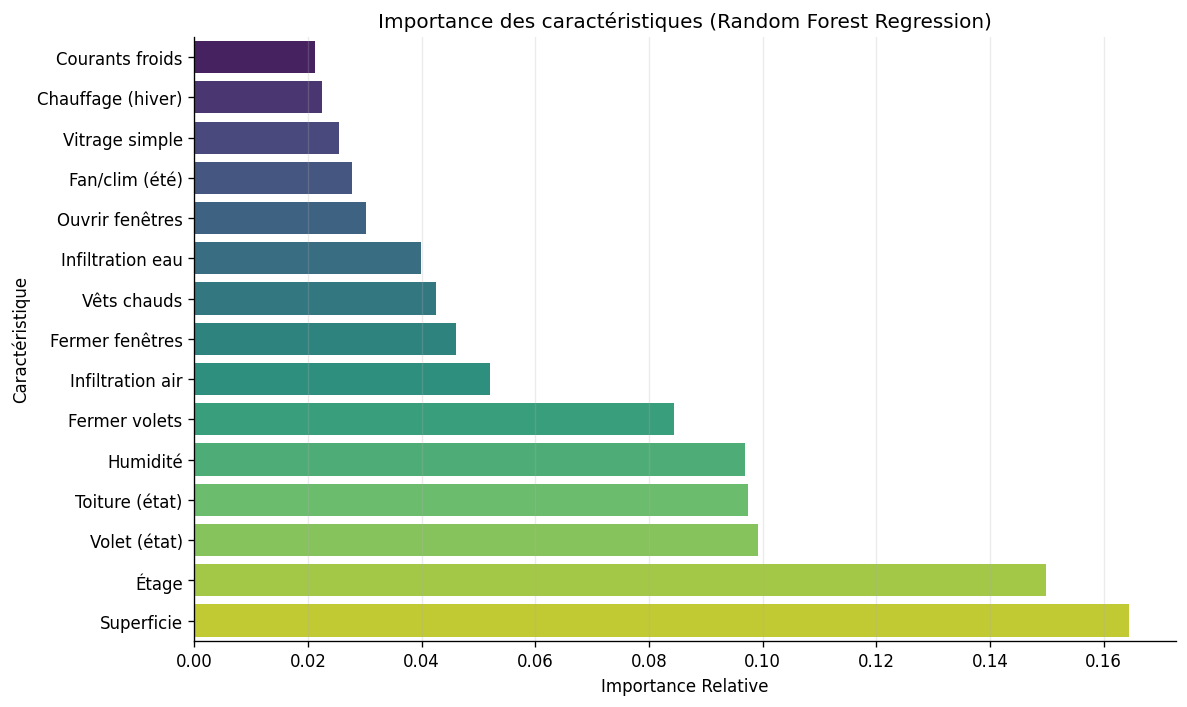

In [15]:
# Re-executing the Random Forest Regression feature importance plot code
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Re-defining dependencies for imp_df to ensure it's available
# This assumes 'df' is already defined in the kernel from previous successful cell execution.
rf_features = {
    "Infiltration air":"infiltr_air_bin","Infiltration eau":"infiltr_eau_bin",
    "Humidité":"humidite_bin","Courants froids":"courants_froids_bin",
    "Vitrage simple":"vitrage_simple_bin","Fan/clim (été)":"beh_fan_ac",
    "Fermer volets":"beh_volets_ete","Ouvrir fenêtres":"beh_fen_ouv",
    "Chauffage (hiver)":"beh_chauffage","Vêts chauds":"beh_vets_chauds",
    "Fermer fenêtres":"beh_fen_ferm","Superficie":"superficie","Étage":"etage",
    "Volet (état)":"volet_etat_num","Toiture (état)":"toiture_etat_num",
}
feat_cols = list(rf_features.values())
feat_labels = list(rf_features.keys())
rf_df = df[feat_cols+["score_confort"]].dropna()
X_rf = rf_df[feat_cols].values; y_rf = rf_df["score_confort"].values
rf_reg = RandomForestRegressor(n_estimators=500,max_depth=4,min_samples_leaf=6,
                                max_features="sqrt",random_state=42)
rf_reg.fit(X_rf,y_rf)
imp_df = pd.DataFrame({"Feature":feat_labels,"Importance":rf_reg.feature_importances_}
                       ).sort_values("Importance",ascending=True)

fig_rf_reg = plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")
plt.title("Importance des caractéristiques (Random Forest Regression)")
plt.xlabel("Importance Relative")
plt.ylabel("Caractéristique")
plt.tight_layout()
plt.show()

### Importance des caractéristiques (Random Forest Classification) - Regenerated Plot

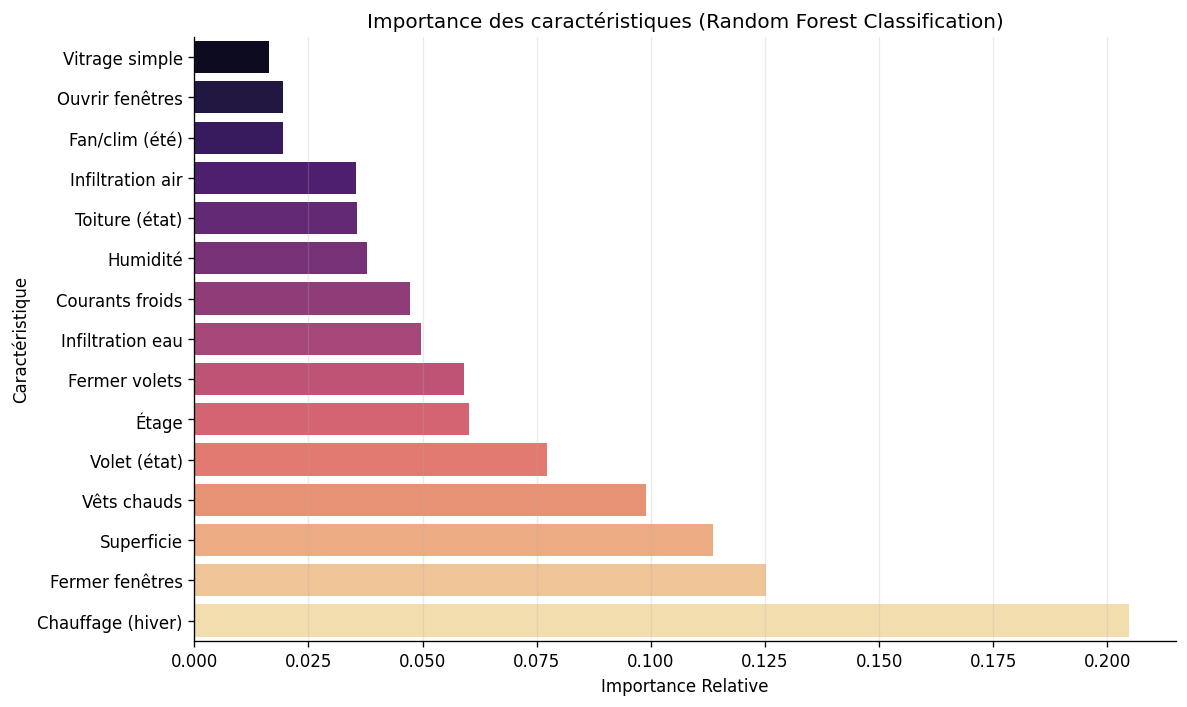

In [16]:
# Re-executing the Random Forest Classification feature importance plot code
fig_rf_clf = plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_df2, palette="magma")
plt.title("Importance des caractéristiques (Random Forest Classification)")
plt.xlabel("Importance Relative")
plt.ylabel("Caractéristique")
plt.tight_layout()
plt.show()

### Importance des caractéristiques (Random Forest Regression)

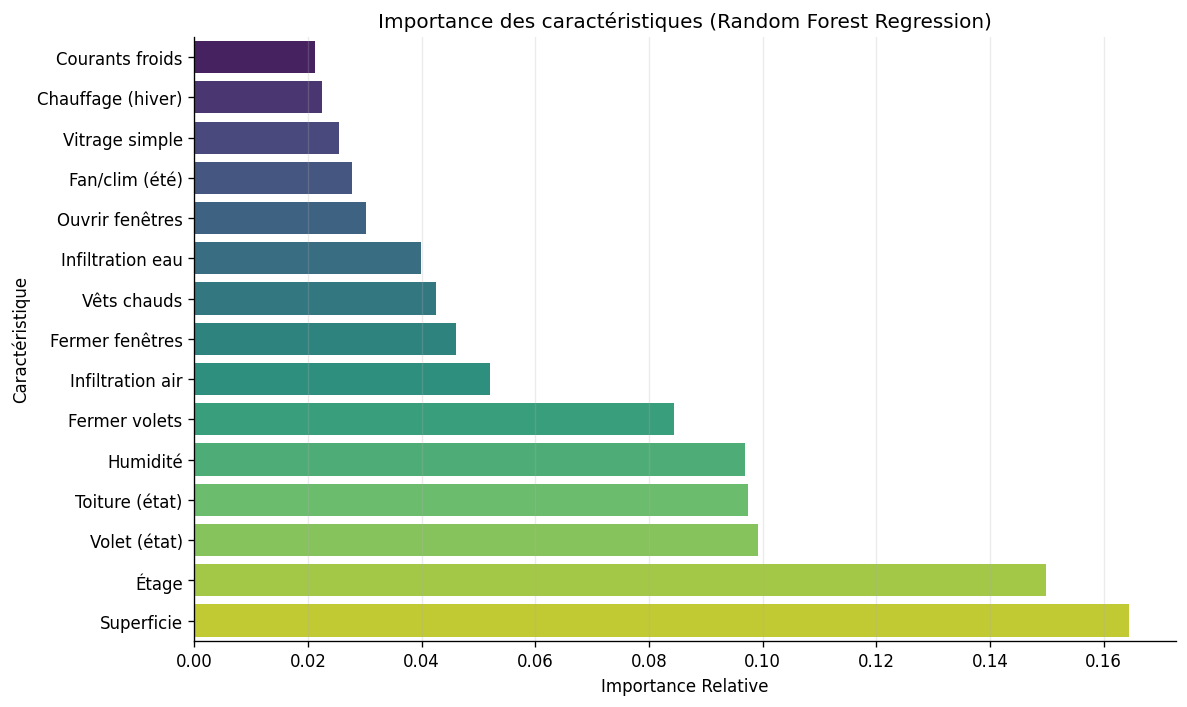

In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Re-defining dependencies for imp_df to ensure it's available
# This assumes 'df' is already defined in the kernel from previous successful cell execution.
rf_features = {
    "Infiltration air":"infiltr_air_bin","Infiltration eau":"infiltr_eau_bin",
    "Humidité":"humidite_bin","Courants froids":"courants_froids_bin",
    "Vitrage simple":"vitrage_simple_bin","Fan/clim (été)":"beh_fan_ac",
    "Fermer volets":"beh_volets_ete","Ouvrir fenêtres":"beh_fen_ouv",
    "Chauffage (hiver)":"beh_chauffage","Vêts chauds":"beh_vets_chauds",
    "Fermer fenêtres":"beh_fen_ferm","Superficie":"superficie","Étage":"etage",
    "Volet (état)":"volet_etat_num","Toiture (état)":"toiture_etat_num",
}
feat_cols = list(rf_features.values())
feat_labels = list(rf_features.keys())
rf_df = df[feat_cols+["score_confort"]].dropna()
X_rf = rf_df[feat_cols].values; y_rf = rf_df["score_confort"].values
rf_reg = RandomForestRegressor(n_estimators=500,max_depth=4,min_samples_leaf=6,
                                max_features="sqrt",random_state=42)
rf_reg.fit(X_rf,y_rf)
imp_df = pd.DataFrame({"Feature":feat_labels,"Importance":rf_reg.feature_importances_}
                       ).sort_values("Importance",ascending=True)

fig_rf_reg = plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")
plt.title("Importance des caractéristiques (Random Forest Regression)")
plt.xlabel("Importance Relative")
plt.ylabel("Caractéristique")
plt.tight_layout()
plt.show()

### Importance des caractéristiques (Random Forest Classification)

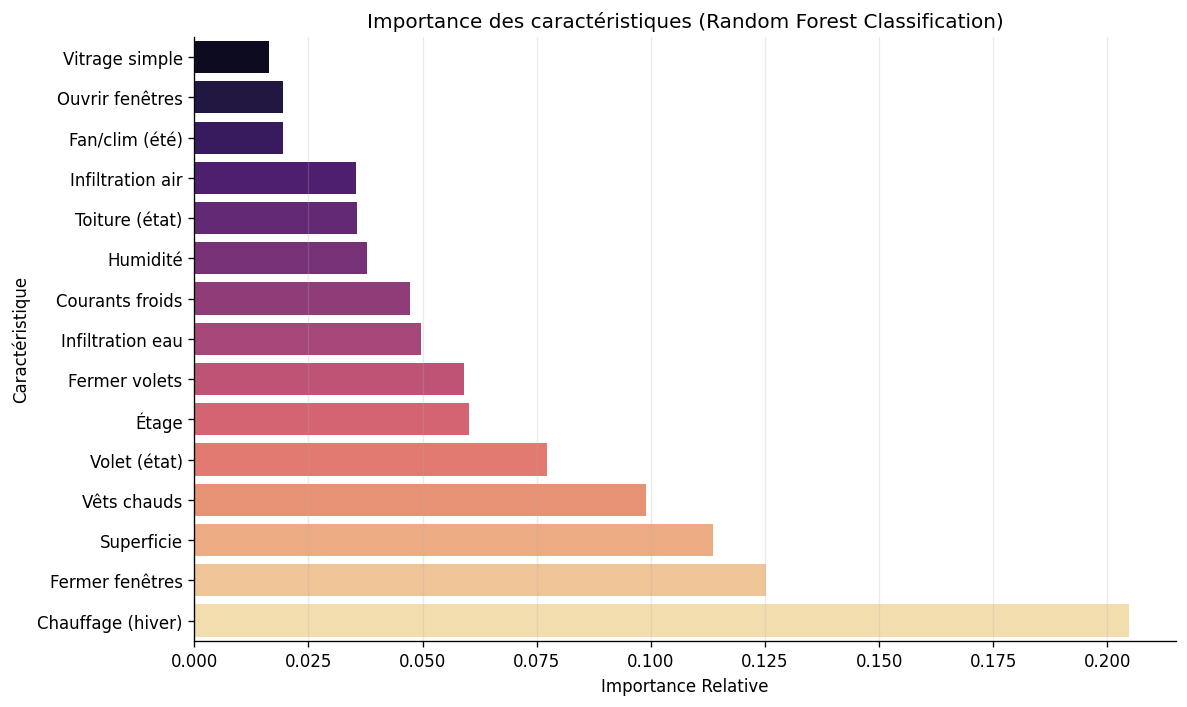

In [18]:
fig_rf_clf = plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_df2, palette="magma")
plt.title("Importance des caractéristiques (Random Forest Classification)")
plt.xlabel("Importance Relative")
plt.ylabel("Caractéristique")
plt.tight_layout()
plt.show()

### Méthode du Coude et Scores de Silhouette pour le Clustering

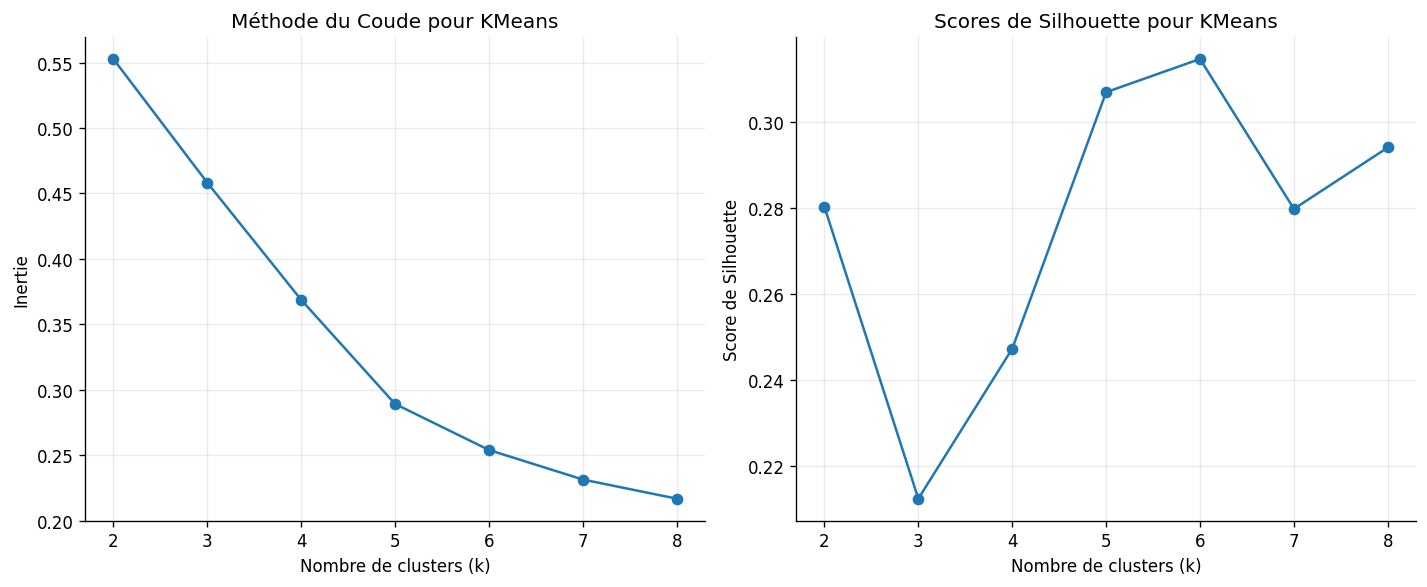

In [19]:
fig_kmeans = plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 9), inertias, marker='o')
plt.title("Méthode du Coude pour KMeans")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, 9), sil_scores, marker='o')
plt.title("Scores de Silhouette pour KMeans")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de Silhouette")
plt.grid(True)
plt.tight_layout()
plt.show()

### Visualisation des Clusters sur les Composantes Principales de l'ACM

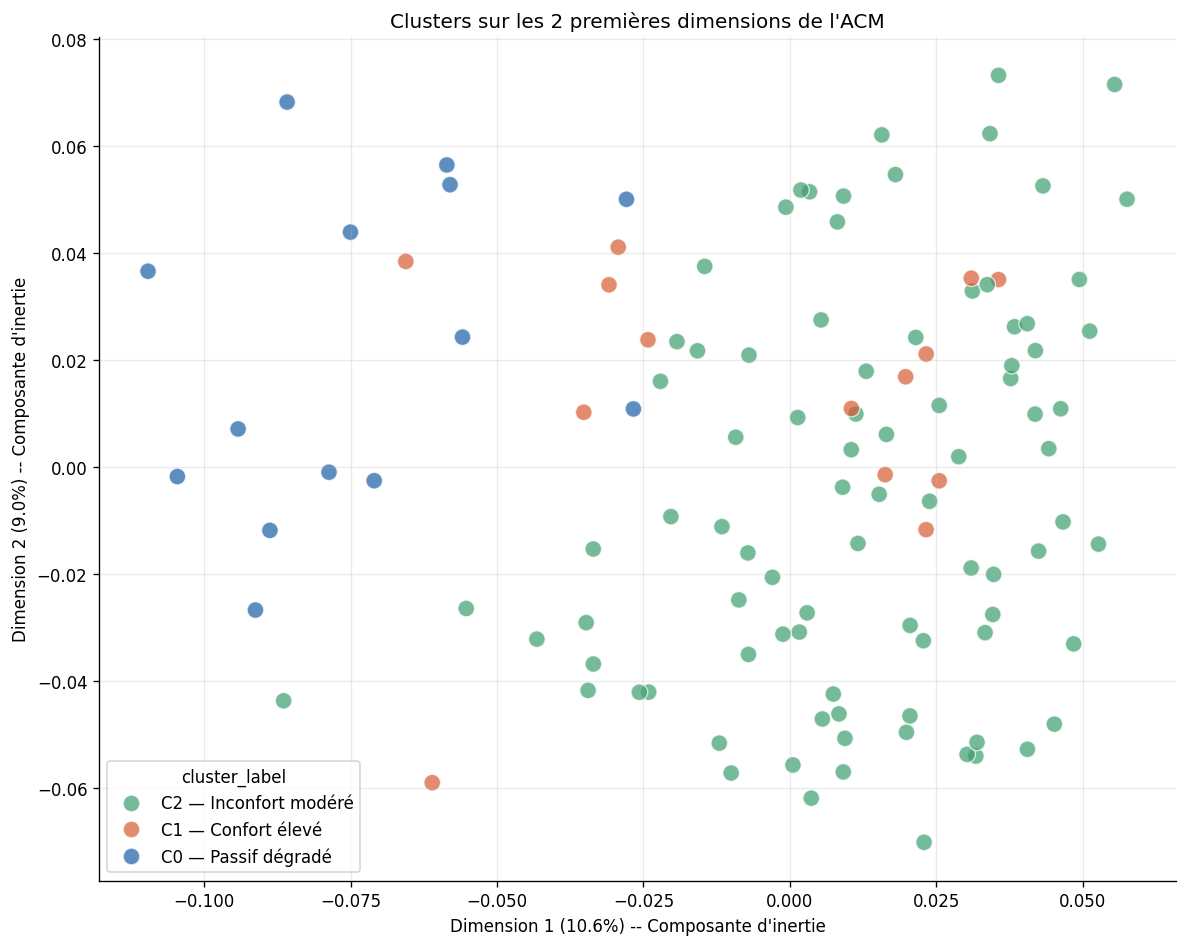

In [20]:
fig_acm_clusters = plt.figure(figsize=(10, 8))
# Create a new palette mapping full cluster labels to colors
plot_palette = {cluster_names[k]: PAL[f"C{k}"] for k in cluster_names.keys()}
sns.scatterplot(
    x=F[:, 0], y=F[:, 1], hue=df.loc[acm_raw.index, "cluster_label"],
    palette=plot_palette, legend="full", s=100, alpha=0.7
)
plt.title("Clusters sur les 2 premières dimensions de l'ACM")
plt.xlabel(f"Dimension 1 ({exp_pct[0]:.1f}%) -- Composante d'inertie")
plt.ylabel(f"Dimension 2 ({exp_pct[1]:.1f}%) -- Composante d'inertie")
plt.grid(True)
plt.tight_layout()
plt.show()

### Analyse des Caractéristiques par Cluster

In [21]:
# Features numériques à analyser
num_features = [
    "superficie", "etage", "score_confort", "sensation_num",
    "sat_ete_num", "sat_hiver_num", "volet_etat_num", "toiture_etat_num"
]

# Features binaires (où la moyenne représente la proportion de "Oui" ou "1")
bin_features = [
    "infiltr_air_bin", "infiltr_eau_bin", "humidite_bin", "courants_froids_bin",
    "vitrage_simple_bin", "beh_fan_ac", "beh_volets_ete", "beh_fen_ouv",
    "beh_chauffage", "beh_vets_chauds", "beh_fen_ferm"
]

# Autres features catégorielles pour lesquelles le mode est pertinent
cat_features = [
    "orientation", "mat_fenetres", "vitrage_type", "volet_etat", "toiture_etat",
    "sensation", "sat_ete", "sat_hiver"
]

# Préparer le DataFrame pour l'analyse par cluster
df_clust_analysis = df.dropna(subset=["cluster_label"]).copy()

print("\n--- Moyennes des features numériques par cluster ---")
display(df_clust_analysis.groupby('cluster_label')[num_features].mean().round(2))

print("\n--- Proportions (moyennes) des features binaires par cluster (1 = Oui/Présent) ---")
display(df_clust_analysis.groupby('cluster_label')[bin_features].mean().round(2))

print("\n--- Modes des features catégorielles par cluster ---")
mode_results = {}
for col in cat_features:
    # Get the value counts for each cluster for the current column
    temp_df = df_clust_analysis.groupby('cluster_label')[col].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    mode_results[col] = temp_df

display(pd.DataFrame(mode_results))


--- Moyennes des features numériques par cluster ---


,superficie,etage,score_confort,sensation_num,sat_ete_num,sat_hiver_num,volet_etat_num,toiture_etat_num
cluster_label,,,,,,,,
C0 — Passif dégradé,69.93,3.21,6.43,0.00,-0.93,-0.43,0.64,1.00
C1 — Confort élevé,96.57,3.29,8.36,0.17,0.50,0.71,1.36,0.93
C2 — Inconfort modéré,105.72,3.83,6.11,-0.38,-1.03,-0.90,1.17,1.15
nan,83.11,2.89,6.89,-0.38,-0.22,-0.56,NaN,1.00



--- Proportions (moyennes) des features binaires par cluster (1 = Oui/Présent) ---


,infiltr_air_bin,infiltr_eau_bin,humidite_bin,courants_froids_bin,vitrage_simple_bin,beh_fan_ac,beh_volets_ete,beh_fen_ouv,beh_chauffage,beh_vets_chauds,beh_fen_ferm
cluster_label,,,,,,,,,,,
C0 — Passif dégradé,0.79,0.64,0.50,0.50,1.00,0.64,0.14,0.43,0.00,0.71,1.00
C1 — Confort élevé,0.57,0.86,0.21,0.93,0.79,0.64,0.00,0.50,0.93,0.07,0.14
C2 — Inconfort modéré,0.65,0.56,0.33,0.74,0.91,0.84,0.30,0.30,0.98,0.05,0.24
nan,0.44,0.56,0.33,0.67,0.78,0.78,0.00,0.33,0.89,0.11,0.22



--- Modes des features catégorielles par cluster ---


,orientation,mat_fenetres,vitrage_type,volet_etat,toiture_etat,sensation,sat_ete,sat_hiver
cluster_label,,,,,,,,
C0 — Passif dégradé,North,Wood,Single glazing,Degraded,Degraded,0 Neutral,-2 dissatisfied,0 Acceptable
C1 — Confort élevé,"North, East, West, South",Wood,Single glazing,Good,Degraded,0 Neutral,+1 Somewhat satisfied,+1 Somewhat satisfied
C2 — Inconfort modéré,South,Wood,Single glazing,Good,Good,0 Neutral,-2 dissatisfied,0 Acceptable
nan,"North, East, West, South",Wood,Single glazing,NaN,Medium,0 Neutral,0 Acceptable,-1 Somewhat dissatisfied


### Visualisation des Clusters sur les Dimensions 3 et 4 de l'ACM

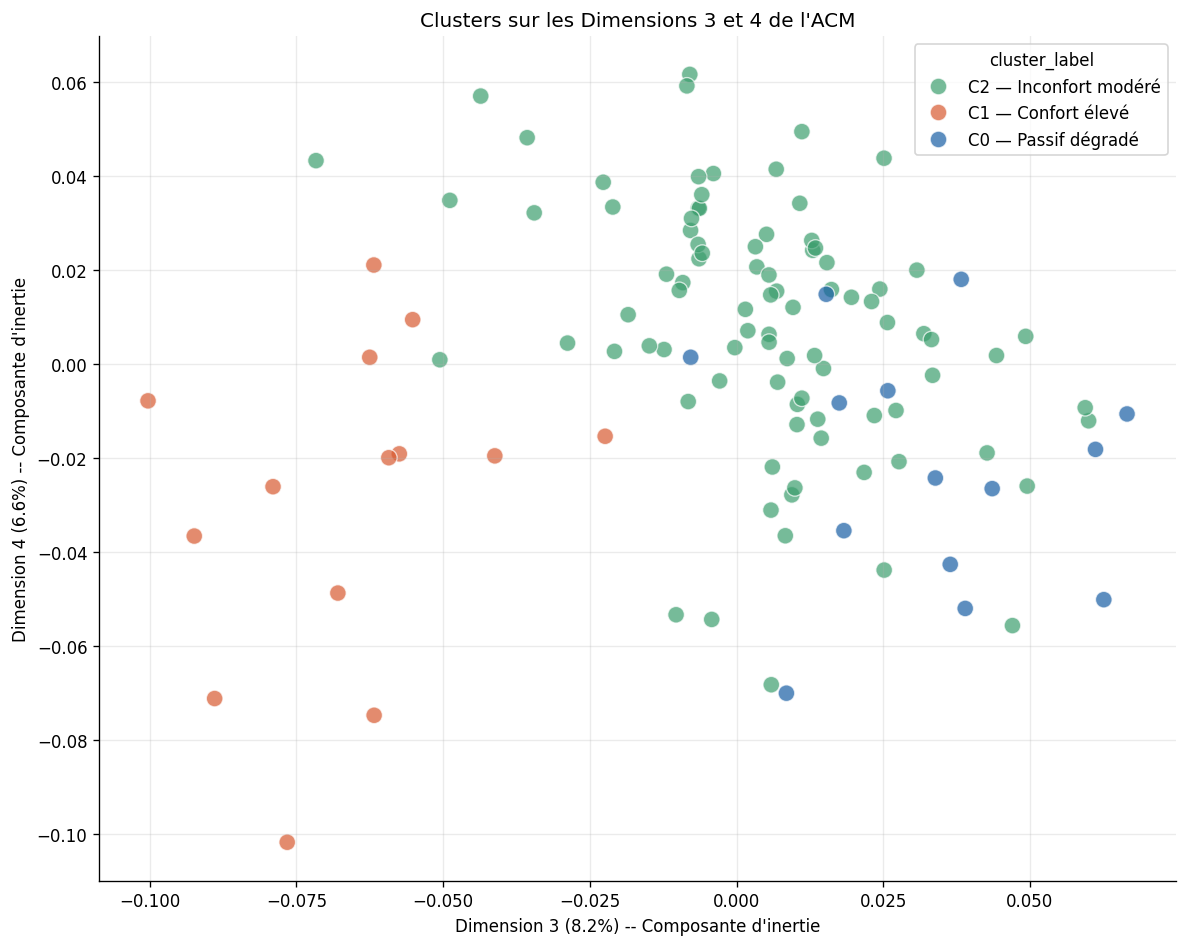

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.linalg import svd
from scipy.cluster.hierarchy import fcluster, linkage # Needed for cluster_label creation
from sklearn.cluster import KMeans # Needed for inertias/sil_scores if recreated

# --- Re-initialize global variables and dataframes if they are missing ---
PAL = {"C0": "#185FA5", "C1": "#D85A30", "C2": "#3C9E6E"}
cluster_names = {0:"C0 — Passif dégradé",1:"C1 — Confort élevé",2:"C2 — Inconfort modéré"}

# --- Re-load and preprocess data to ensure df, acm_raw, F, exp_pct are defined ---
df_raw = pd.read_excel("/content/article_rymel.xlsx", sheet_name="nouha_draft")
RENAME = {
    "Age":"age","Area (m²)":"superficie","Floor":"etage",
    "Are you on the top floor ?":"dernier_etage","Facade orientation":"orientation",
    "Windows material":"mat_fenetres","Glass type":"vitrage_type",
    "Single glazing":"vitrage_simple","Double glazing":"vitrage_double",
    "Shutter state":"volet_etat","Roof waterproofing status":"toiture_etat",
    "Does air get through closed windows?":"infiltr_air",
    "Water infiltration":"infiltr_eau","Moisture and mold":"humidite",
    "Do you experience cold drafts frequently?":"courants_froids",
    "How would you rate the temperature in the rooms facing the street (or the main facade)?":"sensation",
    "Summer thermal satisfaction":"sat_ete","Winter thermal satisfaction":"sat_hiver",
    "Rate thermal comfort":"score_confort",
    "Turn on a fan/the AC":"beh_fan_ac","Close the shutters":"beh_volets_ete",
    "Open the windows":"beh_fen_ouv"," Put on lighter clothes":"beh_vets_legers",
    "Turn on or turn up the heating":"beh_chauffage",
    "Put on warmer clothes":"beh_vets_chauds","Close the windows":"beh_fen_ferm",
    "Occupant status":"statut",
}
df = df_raw.rename(columns={k:v for k,v in RENAME.items() if k in df_raw.columns})

sat_map = {"-2 dissatisfied":-2,"-1 Somewhat dissatisfied":-1,
           "0 Acceptable":0,"+1 Somewhat satisfied":1,"+2 Satisfied":2}
for col in ["sat_ete","sat_hiver"]:
    df[col+"_num"] = df[col].map(sat_map)

sens_map = {"-2 Very cold":-2,"-2 Cold":-2,"-1 Slightly chilly":-1,
            "-1 Cool":-1,"0 Neutral":0,"0 Comfortable":0,"+1 Slightly hot":1,"+2 Hot":2}
df["sensation_num"] = df["sensation"].map(sens_map)

for col in ["infiltr_air","infiltr_eau","humidite","courants_froids"]:
    df[col+"_bin"] = (df[col]=="Yes").astype(int)

df["vitrage_simple_bin"] = df["vitrage_type"].apply(
    lambda x: 0 if ("Double" in str(x) and "Single" not in str(x)) else 1)

for col, mapping in [("volet_etat",{"Good":2,"Medium":1,"Degraded":0}),
                     ("toiture_etat",{"Good":2,"Medium":1,"Degraded":0})]:
    df[col+"_num"] = df[col].map(mapping)

# --- ACM Calculation ---
acm_raw = pd.DataFrame({
    "Sensation":df["sensation"],"Sat_Ete":df["sat_ete"],"Sat_Hiver":df["sat_hiver"],
    "Fan_AC":df["beh_fan_ac"].map({1:"Fan_Oui",0:"Fan_Non"}),
    "Volets_Ete":df["beh_volets_ete"].map({1:"Vol_Oui",0:"Vol_Non"}),
    "Fen_Ouv":df["beh_fen_ouv"].map({1:"FenO_Oui",0:"FenO_Non"}),
    "Chauffage":df["beh_chauffage"].map({1:"Chauf_Oui",0:"Chauf_Non"}),
    "Vets_Chauds":df["beh_vets_chauds"].map({1:"VW_Oui",0:"VW_Non"}),
    "Fen_Ferm":df["beh_fen_ferm"].map({1:"FenF_Oui",0:"FenF_Non"}),
    "Infiltr_Air":df["infiltr_air"],"Infiltr_Eau":df["infiltr_eau"],
    "Humidite":df["humidite"],"Courants":df["courants_froids"],
    "Vitrage":df["vitrage_type"].apply(lambda x: "Double" if "Double" in str(x) and "Single" not in str(x) else "Simple"),
    "Volet_Etat":df["volet_etat"],"Toiture":df["toiture_etat"],
}, index=df.index).dropna()

N_acm, Q = acm_raw.shape
Z = pd.get_dummies(acm_raw, drop_first=False).astype(float)
K = Z.shape[1]
Z_arr = Z.values
n_tot = Z_arr.sum(); r_m = Z_arr.sum(axis=1); c_m = Z_arr.sum(axis=0)
P = Z_arr/n_tot; rc = np.outer(r_m/n_tot, c_m/n_tot)
S = (P-rc)/(np.sqrt(np.outer(r_m/n_tot, c_m/n_tot))+1e-12)
U, sigma, Vt = svd(S, full_matrices=False)
eig = sigma**2
inertia_total = (K-Q)/Q
exp_pct = eig/inertia_total*100
n_dims = 8 # This value was used in original notebook for F
F = U[:,:n_dims]*sigma[:n_dims]

# --- Re-create cluster labels in df ---
X_clust = F[:,:5]
CHOSEN_K = 3 # This value was used in original notebook
Z_link = linkage(X_clust, method="ward")
cah_lab = fcluster(Z_link, t=CHOSEN_K, criterion="maxclust")-1
df.loc[acm_raw.index,"cluster"] = cah_lab
df.loc[acm_raw.index,"cluster_label"] = [cluster_names[c] for c in cah_lab]

# --- Plotting ---
fig_acm_clusters_dim34 = plt.figure(figsize=(10, 8))
plot_palette = {cluster_names[k]: PAL[f"C{k}"] for k in cluster_names.keys()}
sns.scatterplot(
    x=F[:, 2], y=F[:, 3], hue=df.loc[acm_raw.index, "cluster_label"],
    palette=plot_palette, legend="full", s=100, alpha=0.7
)
plt.title("Clusters sur les Dimensions 3 et 4 de l'ACM")
plt.xlabel(f"Dimension 3 ({exp_pct[2]:.1f}%) -- Composante d'inertie")
plt.ylabel(f"Dimension 4 ({exp_pct[3]:.1f}%) -- Composante d'inertie")
plt.grid(True)
plt.tight_layout()
plt.show()